In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import os

torch.manual_seed(42)
np.random.seed(42)

In [2]:
# ✅ Load pre-split normalized data
X_train = np.load("./ecg_ssl_research/data/processed/X_train.npy")
X_val   = np.load("./ecg_ssl_research/data/processed/X_val.npy")
X_test  = np.load("./ecg_ssl_research/data/processed/X_test.npy")
y_train = np.load("./ecg_ssl_research/data/processed/y_train.npy")
y_val   = np.load("./ecg_ssl_research/data/processed/y_val.npy")
y_test  = np.load("./ecg_ssl_research/data/processed/y_test.npy")

# Pretraining data for reconstruction viz
X_pretrain = np.load("./ecg_ssl_research/data/processed/X.npy")

print(f"Test  size: {X_test.shape}")
print(f"Pretrain size: {X_pretrain.shape}")

Test  size: (16942, 180)
Pretrain size: (84708, 180)


In [3]:
class ECGDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class ECGPretrainDataset(torch.utils.data.Dataset):
    def __init__(self, X):
        self.X = torch.tensor(X, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx]

test_loader     = DataLoader(ECGDataset(X_test, y_test),
                             batch_size=64, shuffle=False)
pretrain_loader = DataLoader(ECGPretrainDataset(X_pretrain),
                             batch_size=128, shuffle=True)

In [4]:
class ECGAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 32, 7, padding=3), nn.BatchNorm1d(32),  nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, 5, padding=2), nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, 3, padding=1), nn.BatchNorm1d(128), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(128, 64, 2, stride=2), nn.BatchNorm1d(64), nn.ReLU(),
            nn.ConvTranspose1d(64, 32, 2, stride=2),  nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 1, 3, padding=1)
        )
    def forward(self, x):
        x = x.unsqueeze(1)
        return self.decoder(self.encoder(x)).squeeze(1)


class ECGClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 32, 7, padding=3), nn.BatchNorm1d(32),  nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, 5, padding=2), nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, 3, padding=1), nn.BatchNorm1d(128), nn.ReLU(),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 3)
        )
    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.encoder(x)
        x = self.pool(x).squeeze(-1)
        return self.fc(x)


# Baseline is identical architecture — just no pretrained weights
ECGBaseline = ECGClassifier

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ✅ Load FULL autoencoder (encoder + decoder both)
autoencoder = ECGAutoencoder().to(device)
autoencoder.load_state_dict(
    torch.load("./models/pretrained_autoencoder_full.pth",
               map_location=device, weights_only=True)
)
autoencoder.eval()
print("✅ Full autoencoder loaded")

# SSL Fine-tuned classifier
finetuned = ECGClassifier().to(device)
finetuned.load_state_dict(
    torch.load("./models/best_finetuned_model.pth",
               map_location=device, weights_only=True)
)
finetuned.eval()
print("✅ Fine-tuned classifier loaded")

# Baseline classifier
baseline = ECGBaseline().to(device)
baseline.load_state_dict(
    torch.load("./models/best_baseline_model.pth",
               map_location=device, weights_only=True)
)
baseline.eval()
print("✅ Baseline classifier loaded")

✅ Full autoencoder loaded
✅ Fine-tuned classifier loaded
✅ Baseline classifier loaded


In [6]:
def mask_signal(x, mask_ratio=0.3, block_size=5):
    batch, length = x.shape
    num_blocks    = int((length * mask_ratio) / block_size)
    starts        = torch.randint(0, length - block_size, (batch, num_blocks))
    offsets       = torch.arange(block_size).view(1, 1, block_size)
    indices       = (starts.unsqueeze(-1) + offsets).clamp(0, length - 1)
    indices       = indices.view(batch, -1)
    mask          = torch.zeros(batch, length, dtype=torch.bool)
    mask.scatter_(1, indices, True)
    x_masked      = x.clone()
    x_masked[mask] = 0
    return x_masked, mask

In [7]:
label_map = {0: "Normal", 1: "Afib", 2: "VTach"}

def get_predictions(model, loader):
    all_preds = []
    all_true  = []
    all_probs = []

    model.eval()
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            probs   = F.softmax(outputs, dim=1)
            preds   = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_true.extend(y_batch.numpy())
            all_probs.extend(probs.cpu().numpy())

    return (np.array(all_preds),
            np.array(all_true),
            np.array(all_probs))

ft_preds, ft_true, ft_probs = get_predictions(finetuned, test_loader)
bl_preds, bl_true, bl_probs = get_predictions(baseline,  test_loader)

print("Predictions collected")

Predictions collected


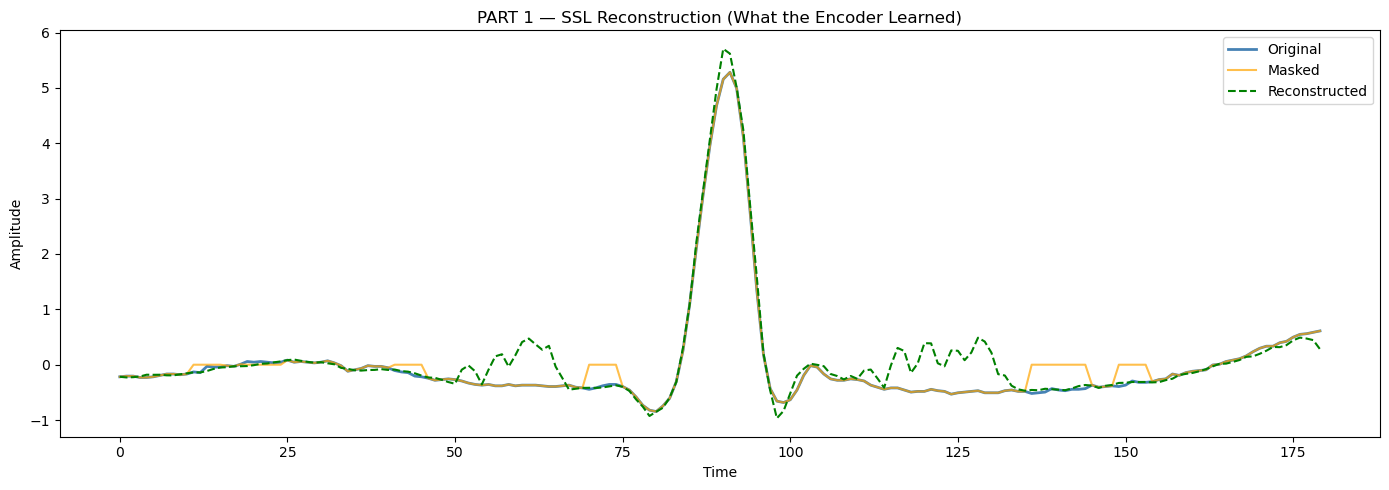

In [8]:
sample   = next(iter(pretrain_loader))[:1].to(device)
masked_x, mask = mask_signal(sample)
masked_x = masked_x.to(device)

with torch.no_grad():
    recon = autoencoder(masked_x)

plt.figure(figsize=(14, 5))
plt.plot(sample[0].cpu(),   label="Original",      linewidth=2, color="steelblue")
plt.plot(masked_x[0].cpu(), label="Masked",        alpha=0.7,  color="orange")
plt.plot(recon[0].cpu(),    label="Reconstructed", linestyle="--", color="green")
plt.title("PART 1 — SSL Reconstruction (What the Encoder Learned)")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()

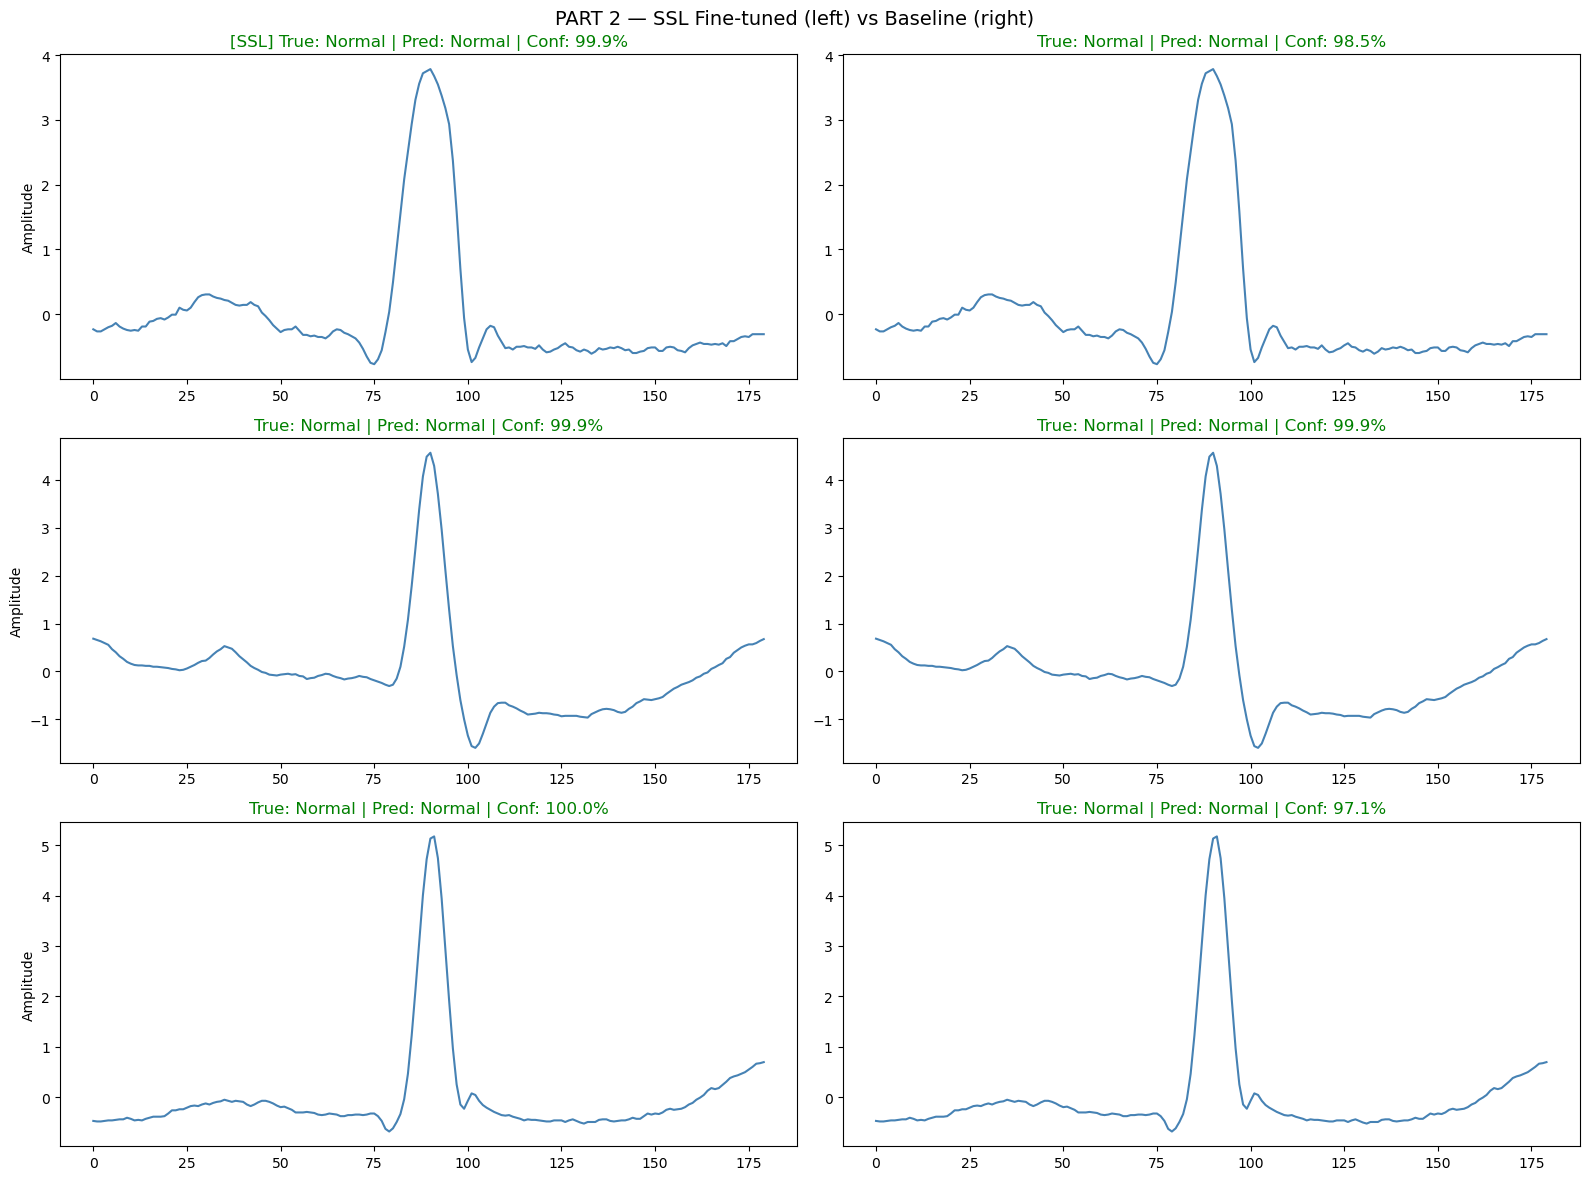

In [9]:
X_batch, y_batch = next(iter(test_loader))
X_batch_dev = X_batch.to(device)

with torch.no_grad():
    ft_out   = finetuned(X_batch_dev)
    bl_out   = baseline(X_batch_dev)
    ft_preds_batch = torch.argmax(ft_out, dim=1).cpu()
    bl_preds_batch = torch.argmax(bl_out, dim=1).cpu()
    ft_probs_batch = F.softmax(ft_out, dim=1).cpu()
    bl_probs_batch = F.softmax(bl_out, dim=1).cpu()

fig, axes = plt.subplots(3, 2, figsize=(16, 12))

for i in range(3):
    signal     = X_batch[i].numpy()
    true_label = label_map[y_batch[i].item()]

    # SSL Fine-tuned
    ft_pred  = label_map[ft_preds_batch[i].item()]
    ft_conf  = ft_probs_batch[i][ft_preds_batch[i].item()].item() * 100
    ft_color = "green" if ft_pred == true_label else "red"

    axes[i][0].plot(signal, color="steelblue")
    axes[i][0].set_title(
        f"True: {true_label} | Pred: {ft_pred} | Conf: {ft_conf:.1f}%",
        color=ft_color
    )
    axes[i][0].set_ylabel("Amplitude")
    if i == 0:
        axes[i][0].set_title(
            f"[SSL] True: {true_label} | Pred: {ft_pred} | Conf: {ft_conf:.1f}%",
            color=ft_color
        )

    # Baseline
    bl_pred  = label_map[bl_preds_batch[i].item()]
    bl_conf  = bl_probs_batch[i][bl_preds_batch[i].item()].item() * 100
    bl_color = "green" if bl_pred == true_label else "red"

    axes[i][1].plot(signal, color="steelblue")
    axes[i][1].set_title(
        f"True: {true_label} | Pred: {bl_pred} | Conf: {bl_conf:.1f}%",
        color=bl_color
    )

fig.suptitle("PART 2 — SSL Fine-tuned (left) vs Baseline (right)", fontsize=14)
plt.tight_layout()
plt.show()

SSL  misclassified: 328
Baseline misclassified: 682


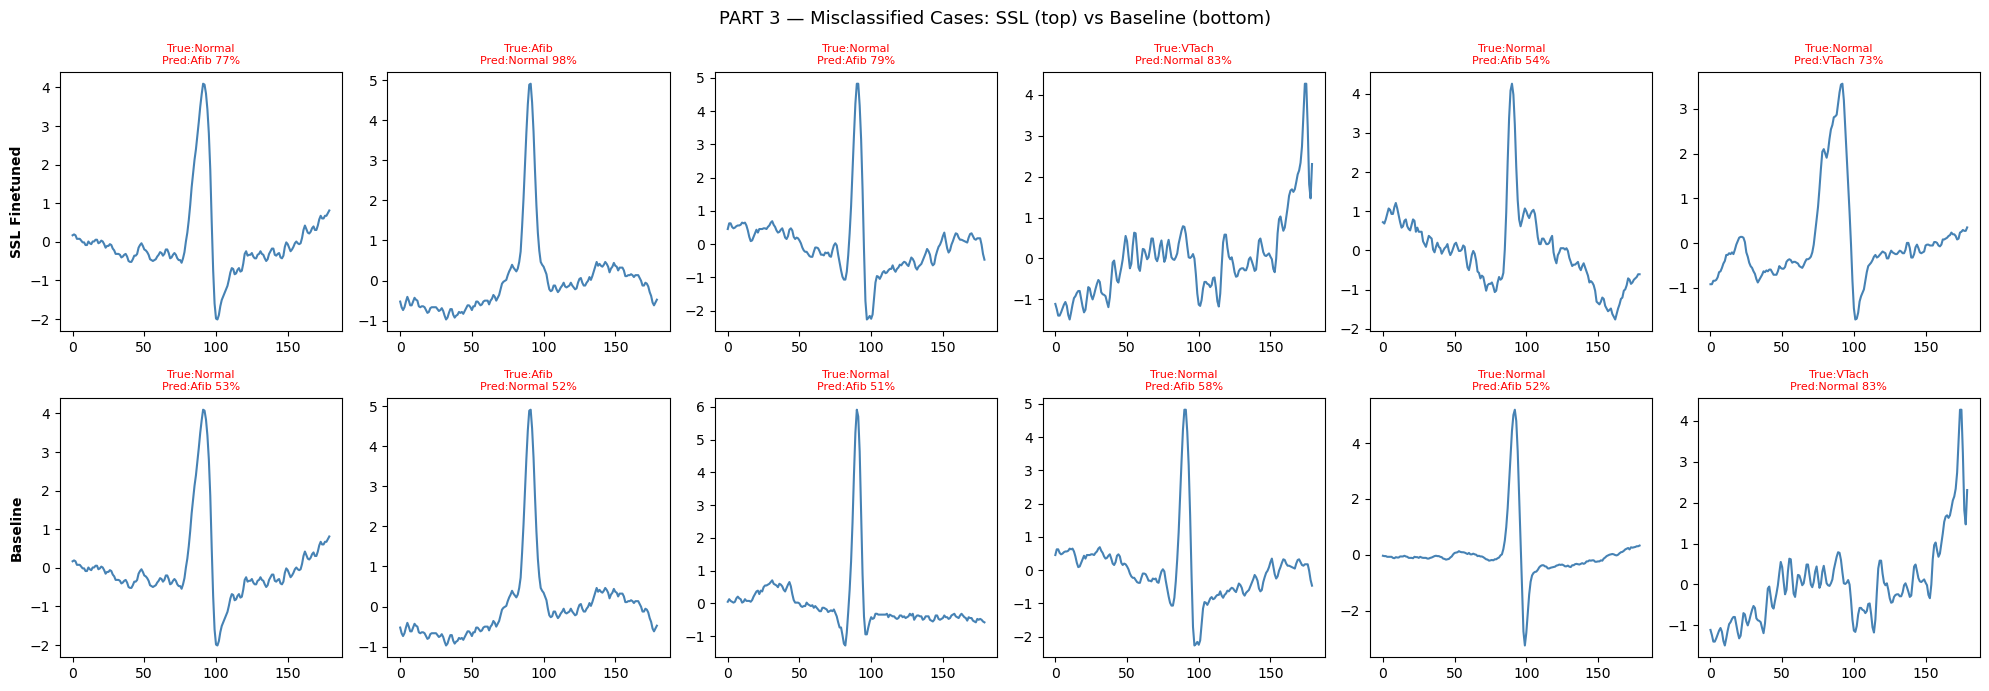

In [10]:
def get_misclassified(preds, true, probs, X_data):
    mistakes = []
    for i in range(len(preds)):
        if preds[i] != true[i]:
            mistakes.append((X_data[i], true[i], preds[i], probs[i]))
    return mistakes

ft_mistakes = get_misclassified(ft_preds, ft_true, ft_probs, X_test)
bl_mistakes = get_misclassified(bl_preds, bl_true, bl_probs, X_test)

print(f"SSL  misclassified: {len(ft_mistakes)}")
print(f"Baseline misclassified: {len(bl_mistakes)}")

fig, axes = plt.subplots(2, 6, figsize=(20, 7))

for i in range(6):
    # SSL mistakes
    if i < len(ft_mistakes):
        sig, true, pred, prob = ft_mistakes[i]
        conf = prob[pred] * 100
        axes[0][i].plot(sig, color="steelblue")
        axes[0][i].set_title(
            f"True:{label_map[true]}\nPred:{label_map[pred]} {conf:.0f}%",
            color="red", fontsize=8
        )

    # Baseline mistakes
    if i < len(bl_mistakes):
        sig, true, pred, prob = bl_mistakes[i]
        conf = prob[pred] * 100
        axes[1][i].plot(sig, color="steelblue")
        axes[1][i].set_title(
            f"True:{label_map[true]}\nPred:{label_map[pred]} {conf:.0f}%",
            color="red", fontsize=8
        )

axes[0][0].set_ylabel("SSL Finetuned", fontsize=10, fontweight='bold')
axes[1][0].set_ylabel("Baseline",      fontsize=10, fontweight='bold')

plt.suptitle("PART 3 — Misclassified Cases: SSL (top) vs Baseline (bottom)",
             fontsize=13)
plt.tight_layout()
plt.show()

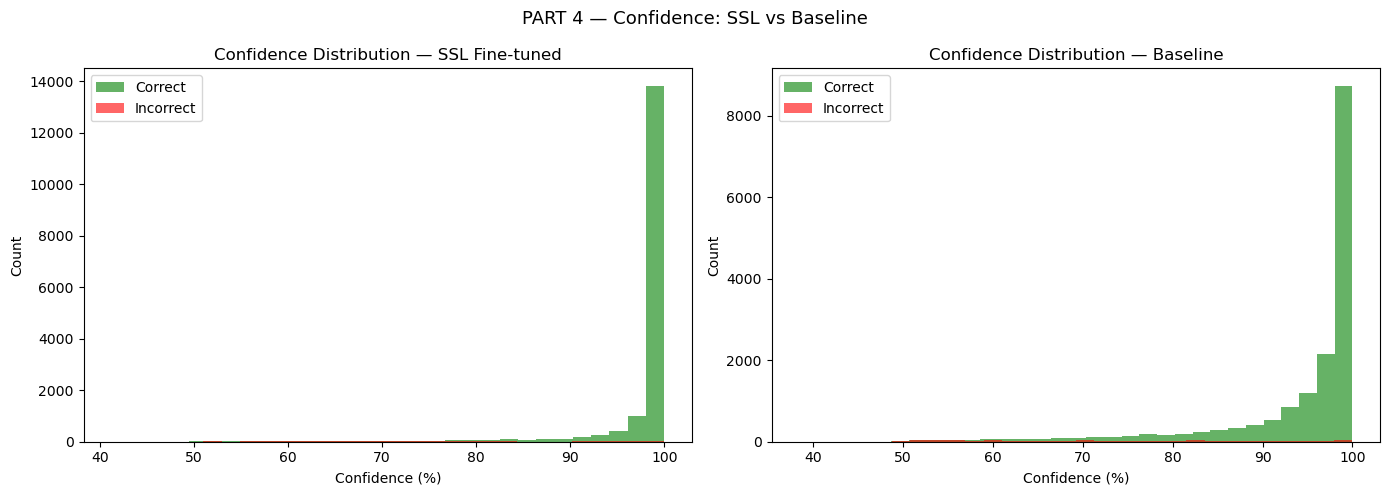

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, probs, true, title in [
    (axes[0], ft_preds, ft_probs, ft_true, "SSL Fine-tuned"),
    (axes[1], bl_preds, bl_probs, bl_true, "Baseline")
]:
    max_conf = probs.max(axis=1) * 100
    correct  = (preds == true)

    ax.hist(max_conf[correct],  bins=30, alpha=0.6,
            label="Correct",   color="green")
    ax.hist(max_conf[~correct], bins=30, alpha=0.6,
            label="Incorrect", color="red")
    ax.set_title(f"Confidence Distribution — {title}")
    ax.set_xlabel("Confidence (%)")
    ax.set_ylabel("Count")
    ax.legend()

plt.suptitle("PART 4 — Confidence: SSL vs Baseline", fontsize=13)
plt.tight_layout()
plt.show()

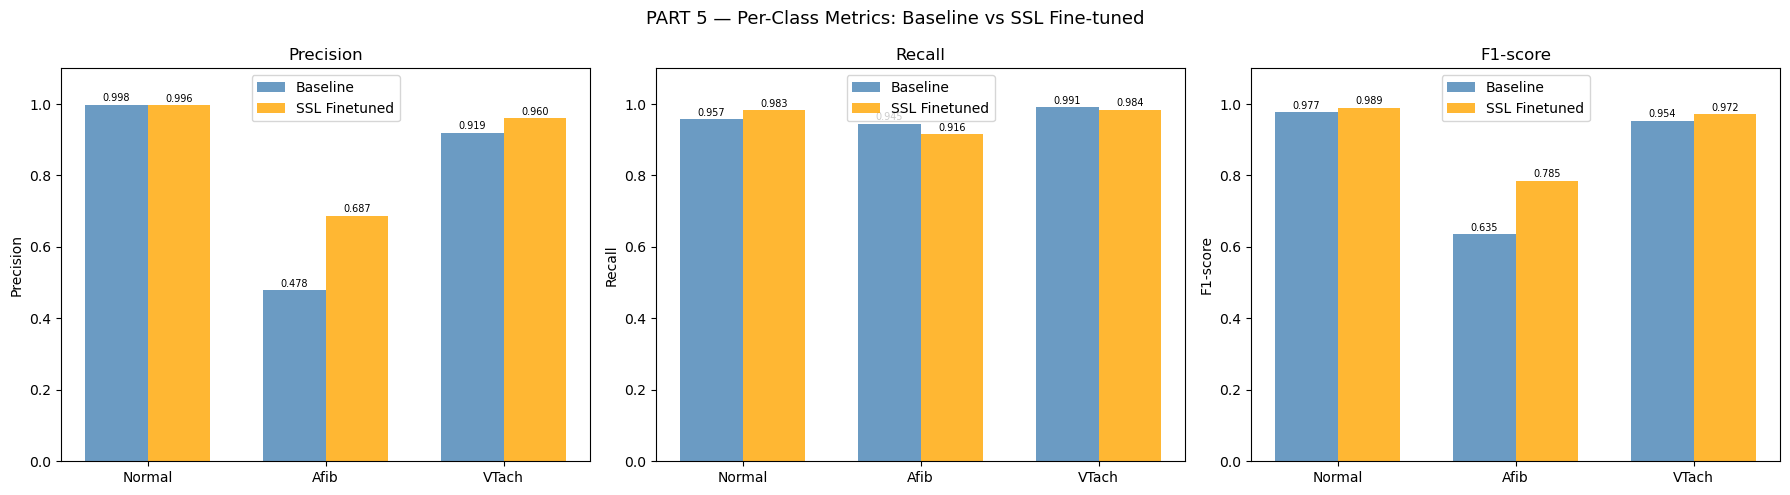

In [12]:
from sklearn.metrics import classification_report

ft_report = classification_report(ft_true, ft_preds, output_dict=True)
bl_report = classification_report(bl_true, bl_preds, output_dict=True)

classes  = ["Normal", "Afib", "VTach"]
keys     = ["0", "1", "2"]
metrics  = ["precision", "recall", "f1-score"]
x        = np.arange(len(classes))
width    = 0.35

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric in zip(axes, metrics):
    ft_vals = [ft_report[k][metric] for k in keys]
    bl_vals = [bl_report[k][metric] for k in keys]

    bars1 = ax.bar(x - width/2, bl_vals, width,
                   label="Baseline", color="steelblue", alpha=0.8)
    bars2 = ax.bar(x + width/2, ft_vals, width,
                   label="SSL Finetuned", color="orange", alpha=0.8)

    ax.set_title(metric.capitalize())
    ax.set_xticks(x)
    ax.set_xticklabels(classes)
    ax.set_ylim(0, 1.1)
    ax.legend()
    ax.set_ylabel(metric.capitalize())

    # value labels on bars
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f"{bar.get_height():.3f}",
                ha='center', fontsize=7)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f"{bar.get_height():.3f}",
                ha='center', fontsize=7)

plt.suptitle("PART 5 — Per-Class Metrics: Baseline vs SSL Fine-tuned",
             fontsize=13)
plt.tight_layout()
plt.show()

In [13]:
print("=" * 60)
print(f"{'Metric':<25} {'Baseline':>15} {'SSL Finetuned':>15}")
print("=" * 60)

rows = [
    ("Accuracy",        "accuracy",  None),
    ("Normal F1",       "0",         "f1-score"),
    ("Afib Precision",  "1",         "precision"),
    ("Afib Recall",     "1",         "recall"),
    ("Afib F1",         "1",         "f1-score"),
    ("VTach Precision", "2",         "precision"),
    ("VTach Recall",    "2",         "recall"),
    ("VTach F1",        "2",         "f1-score"),
    ("Macro F1",        "macro avg", "f1-score"),
]

for name, key, subkey in rows:
    if subkey is None:
        bl_val = bl_report[key]
        ft_val = ft_report[key]
    else:
        bl_val = bl_report[key][subkey]
        ft_val = ft_report[key][subkey]

    winner = "✅" if ft_val >= bl_val else "❌"
    print(f"{name:<25} {bl_val:>15.4f} {ft_val:>15.4f}  {winner}")

print("=" * 60)
print("✅ = SSL better or equal   ❌ = Baseline better")

Metric                           Baseline   SSL Finetuned
Accuracy                           0.9597          0.9806  ✅
Normal F1                          0.9771          0.9893  ✅
Afib Precision                     0.4781          0.6873  ✅
Afib Recall                        0.9450          0.9155  ❌
Afib F1                            0.6350          0.7852  ✅
VTach Precision                    0.9193          0.9596  ✅
VTach Recall                       0.9909          0.9839  ❌
VTach F1                           0.9538          0.9716  ✅
Macro F1                           0.8553          0.9154  ✅
✅ = SSL better or equal   ❌ = Baseline better
